In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.signal import decimate
import math

# Define distances between sensors
D34 = 6.909
D45 = 6.314
D56 = 6.268
D67 = 7.237

# Define raw data directory and reads parquet file
directory = r"C:\Marcelo\projects\GD"
file_path = os.path.join(directory, "5_bar-B1.parquet")
df = pd.read_parquet(file_path, engine="fastparquet")
df.shape

(23400000, 14)

In [2]:
# Visualize data
df.head()

,Experiment,Point,Sensor,Datetime,Timestamp_s,Temperature_C,HL_ch1,HL_ch2,alpha_ch1,alpha_ch2,JL_mps,JG_mps,Vb,alpha_avg
0,B3,P01,TS3,0 days 00:00:00,0.000,39.85,0.547329,0.537412,0.452671,0.462588,0.108626,0.096465,0.396023,0.253024
1,B3,P01,TS3,0 days 00:00:00.001000,0.001,39.85,0.547330,0.537412,0.452670,0.462588,0.108626,0.096465,0.396023,0.253024
2,B3,P01,TS3,0 days 00:00:00.002000,0.002,39.85,0.547330,0.537412,0.452670,0.462588,0.108626,0.096465,0.396023,0.253024
3,B3,P01,TS3,0 days 00:00:00.003000,0.003,39.85,0.547330,0.537412,0.452670,0.462588,0.108626,0.096465,0.396023,0.253024
4,B3,P01,TS3,0 days 00:00:00.004000,0.004,39.85,0.547330,0.537412,0.452670,0.462588,0.108626,0.096465,0.396023,0.253024


In [3]:
# Generate a Bubble Velocity (Vb) Table per sensor and experimental point
points_to_remove = ["P20", "P21"] # This line removes 2 experimental points that don't characterize as slug flow

unique_vb = (df[~df["Point"].isin(points_to_remove)].groupby(['Point', 'Sensor'], as_index=False)['Vb'].first())

vb_table = unique_vb.pivot(index='Point', columns='Sensor', values='Vb')
vb_table.head(20)

Sensor,TS3,TS4,TS5,TS6,TS7
Point,,,,,
P01,0.396023,0.404598,0.399429,0.423171,0.397126
P02,0.633636,0.617544,0.659434,0.754348,0.590598
P03,1.072308,1.035294,1.075385,1.137705,1.001449
P08,0.611404,0.628571,0.641284,0.654717,0.639815
P09,0.917105,0.891139,0.907792,0.991429,0.863750
P10,1.315094,1.353846,1.318868,1.445833,1.354902
P15,1.056061,1.100000,1.059091,1.119355,1.063077
P16,1.340385,1.380392,1.370588,1.445833,1.382000
P17,1.659524,1.955556,1.792308,1.875676,1.818421


In [4]:
# Filter for sensors TS3..TS7 and Ch1
sensors_to_keep = [f"TS{i}" for i in range(3, 8)]
points_to_remove = ["P20", "P21"]

# Reorganize DataFrame to keep only variables of interest
data = df[(df["Sensor"].isin(sensors_to_keep)) & (~df["Point"].isin(points_to_remove))][["Point", "Sensor", "HL_ch1"]].copy()
data.rename(columns={"Point": "P", "Sensor": "TS", "HL_ch1": "Ch1"}, inplace=True)

# Ensure experiments and sensors are ordered
data["P"] = data["P"].astype("category")
data["TS"] = data["TS"].astype("category")
data["Ch1"] = data["Ch1"].astype("float32")

# Sort for consistency
data = data.sort_values(["P", "TS"]).reset_index(drop=True)
data.head()

,P,TS,Ch1
0,P01,TS3,0.547329
1,P01,TS3,0.547330
2,P01,TS3,0.547330
3,P01,TS3,0.547330
4,P01,TS3,0.547330


In [ ]:
# Reorganize dataset
Ps = data['P'].cat.categories  # get sorted categories
TSs = np.sort(data['TS'].unique())

# Determine time steps
T = len(data) // (len(Ps) * len(TSs))

# Create empty array
arr = np.empty((len(Ps), T, len(TSs)))

# Fill array
for i, p in enumerate(Ps):
    df_p = data[data['P'] == p]
    for j, ts in enumerate(TSs):
        df_pts = df_p[df_p['TS'] == ts].reset_index(drop=True)
        arr[i, :, j] = df_pts['Ch1'].values

print(arr.shape)  # (17, T, 5)

(16, 260000, 5)


In [6]:
# Define useful functions

# Define function for signal decimation
def decimate_array(data, q=1, axis=1):
    n_series, n_timesteps, n_features = data.shape
    new_len = math.ceil(n_timesteps / q)  # ensure correct size
    decimated = np.zeros((n_series, new_len, n_features))

    for i in range(n_series):
        for j in range(n_features):
            decimated[i, :, j] = decimate(data[i, :, j], q, ftype='iir', zero_phase=True)

    return decimated

# Define function to calculate window step
def calculate_step(Vb, D, Q):
    t = D / Vb
    step = t * 1000/Q

    return int(round(step))

In [ ]:
# Decimate signal by a factor of Q
Q = 4
arr_dec = decimate_array(arr, Q)
print(arr_dec.shape)

(16, 65000, 5)


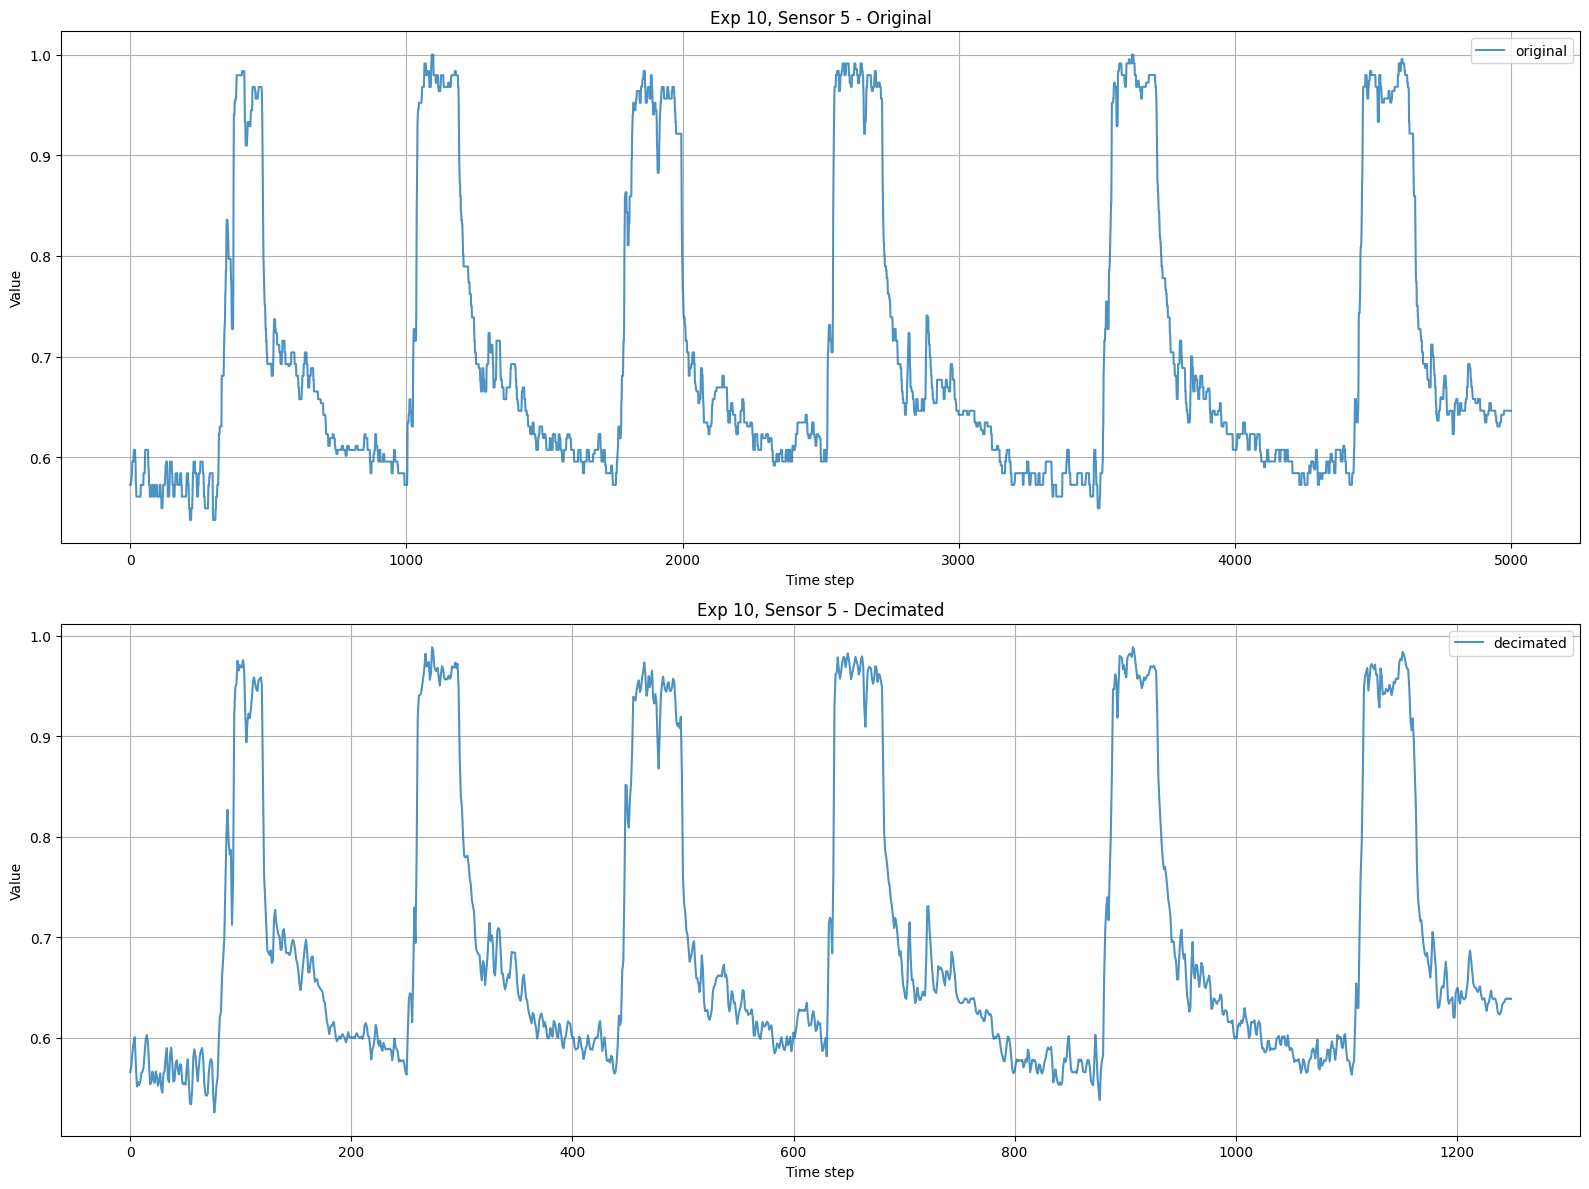

In [9]:
# Signal visualization comparing original and decimated signal
exp = 10
sensor = 5

label1 = arr[exp-1, :5000, sensor-1]
label2 = arr_dec[exp-1, :math.ceil(5000/Q), sensor-1]

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=False)

# Original signal
axes[0].plot(label1, label="original", alpha=0.8)
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Value")
axes[0].set_title(f"Exp {exp}, Sensor {sensor} - Original")
axes[0].legend()
axes[0].grid(True)

# Decimated signal
axes[1].plot(label2, label="decimated", alpha=0.8)
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Value")
axes[1].set_title(f"Exp {exp}, Sensor {sensor} - Decimated")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# SYNCHRONIZED SLIDING WINDOWS FUNCTION
# (with an edge factor for taking centralized target)
# Targeting S5

"""
FOR TIME ALIGNED: Define all steps = 0)
step_1 = 0
step_2 = 0
step_3 = 0
step_4 = 0
target_delay = 0
steps = [step_1, step_2, step_3, step_4]
"""

def create_windows_sensor_with_steps(data, vb_table, calculate_step, window_size=500, target_size=1, target_sensor=4):
    n_series, T, n_features = data.shape

    edge = int((window_size - target_size) / 2)
    X_all, y_all = [], []

    for P in range(n_series):
        # --- Compute steps for this experiment ---
        Vb3 = vb_table.iloc[P]['TS3']
        Vb4 = vb_table.iloc[P]['TS4']
        Vb5 = vb_table.iloc[P]['TS5']
        Vb6 = vb_table.iloc[P]['TS6']

        step34 = calculate_step(Vb3, D34, Q)
        step45 = calculate_step(Vb4, D45, Q)
        step56 = calculate_step(Vb5, D56, Q)
        step67 = calculate_step(Vb6, D67, Q)

        step_1 = 0
        step_2 = step34
        step_3 = step34 + step45
        step_4 = step34 + step45 + step56
        target_delay = step34 + step45 + step56 + step67
        steps = [step_1, step_2, step_3, step_4]

        # --- Determine valid range considering the largest step ---
        n_samples = T - window_size - target_delay + 1

        X_list, y_list = [], []

        for t in range(n_samples):
            window = np.zeros((window_size, n_features - 1))

            # Apply per-feature delays
            for f in range(4):  # first 4 are inputs
                delay = int(steps[f])
                start = t + delay
                end = start + window_size
                window[:, f] = data[P, start:end, f]

            # Target aligned at the end of window
            y_val = data[P, t + target_delay + edge : t + target_delay + edge + target_size, target_sensor]

            X_list.append(window)
            y_list.append(y_val)

        X_series = np.array(X_list)   # shape (n_samples, window_size, n_features)
        y_series = np.array(y_list)   # shape (n_samples, target_size)

        X_all.append(X_series)
        y_all.append(y_series)
    
    return X_all, y_all
    

In [ ]:
# Apply window generation function and print the shapes for each experimental point
X_SEQ = 2000
Y_SEQ = 20
INPUT_CHANNELS = 4

X_data, y_data = create_windows_sensor_with_steps(arr_dec, vb_table, calculate_step, window_size=X_SEQ, target_size=Y_SEQ)

for i in range(0, 16):
    print("X shape:", X_data[i].shape)
    print("y shape:", y_data[i].shape)

In [ ]:
# Split in TRAIN/VAL/TEST and save a npz file for each experimental point

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for i in range(0, 16):
    # Compute indices along the second dimension
    total_timesteps = X_data[i].shape[0]
    train_end = int(total_timesteps * train_ratio)
    val_end = train_end + int(total_timesteps * val_ratio)

    # Slice
    X_train = X_data[i][:train_end, :]
    X_val   = X_data[i][train_end:val_end, :]
    X_test  = X_data[i][val_end:, :]
    y_train = y_data[i][:train_end, :]
    y_val   = y_data[i][train_end:val_end, :]
    y_test  = y_data[i][val_end:, :]

    print(X_train.shape, X_val.shape, X_test.shape)
    print(y_train.shape, y_val.shape, y_test.shape)

    # Save everything in one npz file per array
    filename = f"../Data/P{i+1}_{X_SEQ}_{Y_SEQ}_{INPUT_CHANNELS}.npz"
    np.savez_compressed(filename,
                        X_train=X_train, y_train=y_train,
                        X_val=X_val, y_val=y_val,
                        X_test=X_test, y_test=y_test)
    
    print(f"Saved {filename}")



In [ ]:
# Split in TRAIN/VAL/TEST and save a npz file for train/val/test for all experimental points together

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Lists to accumulate splits
X_train_list, y_train_list = [], []
X_val_list,   y_val_list   = [], []
X_test_list,  y_test_list  = [], []

for i in range(16):
    print(f"Processing experiment {i+1}/16")

    # one experiment at a time
    X = X_data[i]
    y = y_data[i]

    n = X.shape[0]
    train_end = int(n * train_ratio)
    val_end   = train_end + int(n * val_ratio)

    # Slice
    X_train = X[:train_end]
    X_val   = X[train_end:val_end]
    X_test  = X[val_end:]
    y_train = y[:train_end]
    y_val   = y[train_end:val_end]
    y_test  = y[val_end:]

    # Append to global lists
    X_train_list.append(X_train)
    y_train_list.append(y_train)
    X_val_list.append(X_val)
    y_val_list.append(y_val)
    X_test_list.append(X_test)
    y_test_list.append(y_test)

# -------- Final Concatenation ----------
print("Concatenating splits...")

X_train_all = np.concatenate(X_train_list, axis=0)
y_train_all = np.concatenate(y_train_list, axis=0)
print("Finished concatenating train split.")

X_val_all = np.concatenate(X_val_list, axis=0)
y_val_all = np.concatenate(y_val_list, axis=0)
print("Finished concatenating val split.")

X_test_all = np.concatenate(X_test_list, axis=0)
y_test_all = np.concatenate(y_test_list, axis=0)
print("Finished concatenating test split.")

# -------- Save unified files ----------
print("Saving files...")
np.savez_compressed(f"../Data/ALL_train_{X_SEQ}_{Y_SEQ}_{INPUT_CHANNELS}.npz",
                    X=X_train_all, y=y_train_all)
print("Finished saving train file.")

np.savez_compressed(f"../Data/ALL_val_{X_SEQ}_{Y_SEQ}_{INPUT_CHANNELS}.npz",
                    X=X_val_all, y=y_val_all)
print("Finished saving val file.")

np.savez_compressed(f"../Data/ALL_test_{X_SEQ}_{Y_SEQ}_{INPUT_CHANNELS}.npz",
                    X=X_test_all, y=y_test_all)
print("Finished saving test file.")

print("Finished saving files.")